In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Show all columns
pd.set_option('display.max_columns', None)

print("Libraries loaded successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully!


In [2]:
df = pd.read_csv("../data/complaints.csv", low_memory=False)

df.head()

,ID,Company,Product,Issue,State,Submitted via,Date received,Date resolved,Timely response?,Consumer disputed?,state name,Date received.1,Date resolved.1,Resolution time(in days),Year,QTR (US FLY)
0,1615767,PHH Mortgage,Mortgage,"Loan servicing, payments, escrow account",FL,Web,10/20/2015,10/20/2015,Yes,No,Florida,10/20/2015,10/20/2015,0,2015,Q4
1,654223,Ocwen,Mortgage,"Loan servicing, payments, escrow account",NC,Web,3/1/2014,3/1/2014,Yes,No,North Carolina,1/3/2014,1/3/2014,0,2014,Q1
2,1143398,"Southwest Credit Systems, L.P.",Debt collection,"Loan modification,collection,foreclosure",MO,Web,4/12/2014,4/12/2014,Yes,No,Missouri,12/4/2014,12/4/2014,0,2014,Q4
3,1303679,"Continental Finance Company, LLC",Credit card,Billing statement,WA,Web,03/26/2015,03/26/2015,Yes,No,Washington,3/26/2015,3/26/2015,0,2015,Q1
4,1627370,Experian,Credit reporting,Unable to get credit report/credit score,VA,Web,10/27/2015,10/27/2015,Yes,No,Virginia,10/27/2015,10/27/2015,0,2015,Q4


In [3]:
df.shape

(14000, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14000 entries, 0 to 13999
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0    ID                       14000 non-null  int64
 1   Company                   14000 non-null  str  
 2   Product                   14000 non-null  str  
 3   Issue                     14000 non-null  str  
 4   State                     13890 non-null  str  
 5   Submitted via             14000 non-null  str  
 6   Date received             14000 non-null  str  
 7   Date resolved             14000 non-null  str  
 8   Timely response?          14000 non-null  str  
 9   Consumer disputed?        14000 non-null  str  
 10  state name                13843 non-null  str  
 11  Date received.1           14000 non-null  str  
 12  Date resolved.1           14000 non-null  str  
 13  Resolution time(in days)  14000 non-null  int64
 14  Year                      14000 non-null  int64
 

# Complaint Intelligence Dashboard for Financial Services

### Objective

The objective of this project is to analyze customer complaints received by financial institutions, identify complaint trends, understand customer pain points, and generate insights that can support policy formulation and operational decision-making.

### Tools Used
- Python
- Pandas
- Matplotlib
- SQL (next phase)
- Power BI (next phase)


##Dataset Overview

In [17]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])


Rows : 14000
Columns : 16


In [18]:
df.columns.tolist()

[' ID',
 'Company',
 'Product',
 'Issue',
 'State',
 'Submitted via',
 'Date received',
 'Date resolved',
 'Timely response?',
 'Consumer disputed?',
 'state name',
 'Date received.1',
 'Date resolved.1',
 'Resolution time(in days)',
 'Year',
 'QTR (US FLY)']

##Data Quality Assessment

In [19]:
missing = df.isnull().sum().sort_values(ascending=False)

missing

state name                  157
State                       110
Product                       0
 ID                           0
Issue                         0
Submitted via                 0
Date received                 0
Company                       0
Date resolved                 0
Timely response?              0
Consumer disputed?            0
Date received.1               0
Date resolved.1               0
Resolution time(in days)      0
Year                          0
QTR (US FLY)                  0
dtype: int64

In [20]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent.sort_values(ascending=False)

state name                  1.121429
State                       0.785714
Product                     0.000000
 ID                         0.000000
Issue                       0.000000
Submitted via               0.000000
Date received               0.000000
Company                     0.000000
Date resolved               0.000000
Timely response?            0.000000
Consumer disputed?          0.000000
Date received.1             0.000000
Date resolved.1             0.000000
Resolution time(in days)    0.000000
Year                        0.000000
QTR (US FLY)                0.000000
dtype: float64

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["Product"].value_counts()

Product
Mortgage                   3346
Debt collection            2752
Bank account or service    2429
Credit card                2136
Credit reporting           1311
Consumer Loan               877
Student loan                722
Payday loan                 179
Money transfers             131
Prepaid card                 92
Other financial service      24
Virtual currency              1
Name: count, dtype: int64

In [23]:
df["Issue"].value_counts().head(10)

Issue
Loan servicing, payments, escrow account    2354
Account opening, closing, or management     1047
Loan modification,collection,foreclosure     883
Communication tactics                        814
Deposits and withdrawals                     618
Credit reporting company's investigation     574
Application, originator, mortgage broker     535
Billing disputes                             447
False statements or representation           423
Managing the loan or lease                   423
Name: count, dtype: int64

In [24]:
df["Company"].value_counts().head(10)

Company
Bank of America            1066
Wells Fargo & Company       947
JPMorgan Chase & Co.        877
Citibank                    764
Equifax                     531
Capital One                 458
Experian                    456
Ocwen                       437
Navient Solutions, Inc.     350
U.S. Bancorp                309
Name: count, dtype: int64

In [25]:
df["State"].value_counts().head(10)

State
CA    1977
FL    1255
TX    1040
NY     996
GA     577
NJ     518
PA     511
IL     500
VA     480
OH     463
Name: count, dtype: int64

##Exploratory Data Analysis

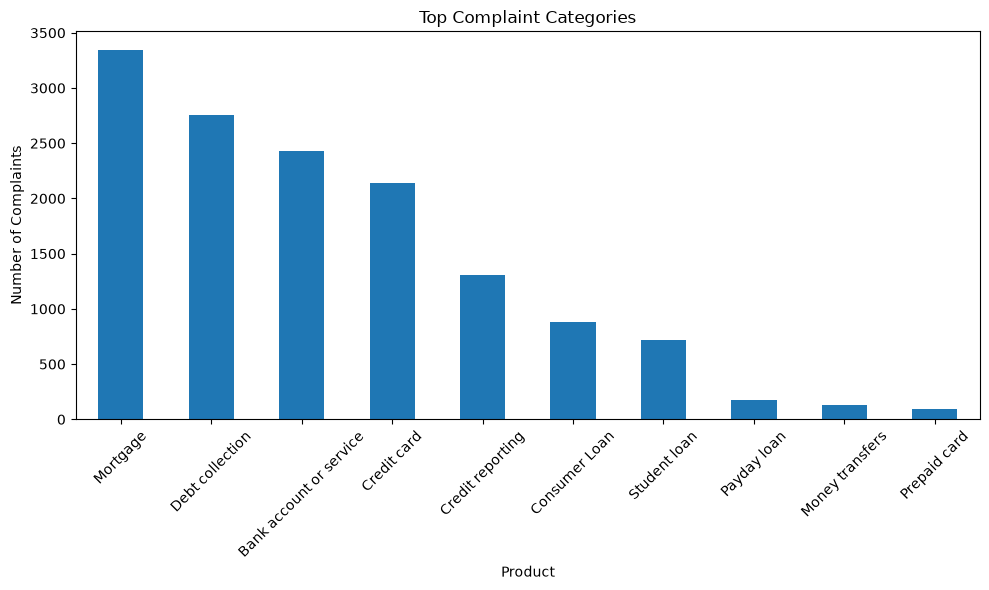

In [26]:
plt.figure(figsize=(10,6))

df["Product"].value_counts().head(10).plot(kind="bar")

plt.title("Top Complaint Categories")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Observation

- Mortgage complaints are the most common complaint category.
- Debt Collection and Bank Account Services are the next major contributors.
- Mortgage-related customer grievances deserve priority attention.
- RBI/Bank management can allocate additional monitoring resources towards high-frequency complaint categories.

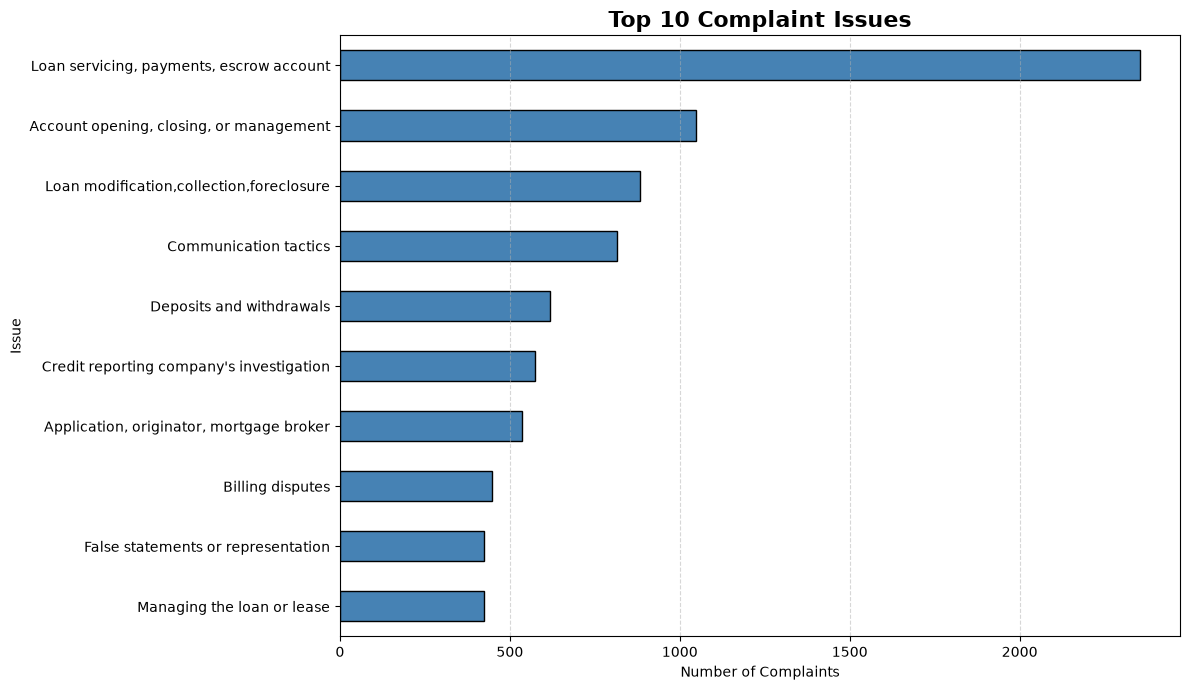

In [27]:
plt.figure(figsize=(12,7))

top_issues = df["Issue"].value_counts().head(10)

top_issues.sort_values().plot(
    kind="barh",
    color="steelblue",
    edgecolor="black"
)

plt.title("Top 10 Complaint Issues", fontsize=16, fontweight="bold")
plt.xlabel("Number of Complaints")
plt.ylabel("Issue")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()

plt.show()

## Observation

- Identified the most recurring customer issues.
- High-frequency issues indicate process weaknesses.
- Banks should prioritise addressing these complaint categories.

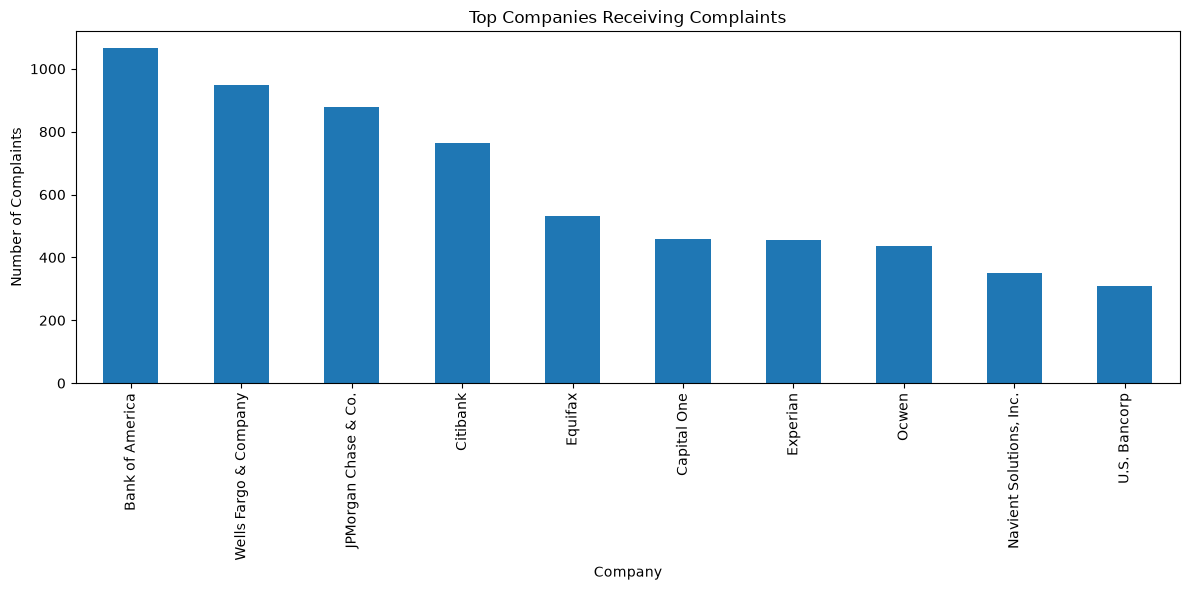

In [28]:
plt.figure(figsize=(12,6))

df["Company"].value_counts().head(10).plot(kind="bar")

plt.title("Top Companies Receiving Complaints")

plt.xlabel("Company")

plt.ylabel("Number of Complaints")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

## Observation

- Complaint concentration varies significantly across institutions.
- High complaint volumes may require additional supervisory attention.

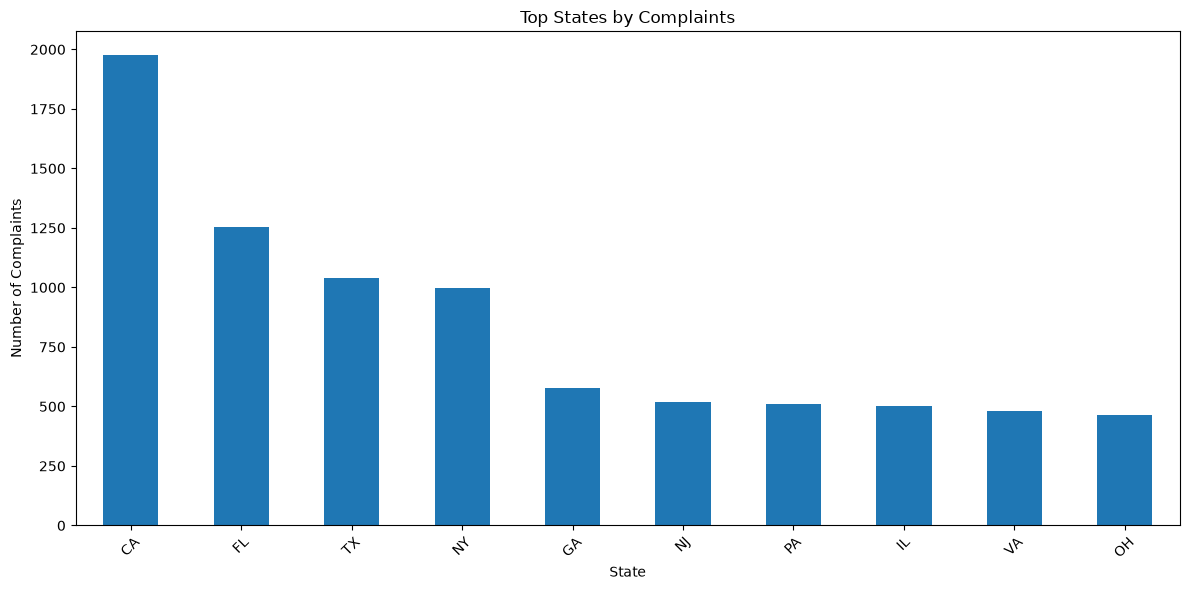

In [29]:
plt.figure(figsize=(12,6))

df["State"].value_counts().head(10).plot(kind="bar")

plt.title("Top States by Complaints")

plt.xlabel("State")

plt.ylabel("Number of Complaints")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


## Observation

- Complaint volumes differ across states.
- Geographic analysis helps identify regions requiring focused consumer awareness and grievance redressal.

# Data Cleaning

In [30]:
df.isnull().sum()

 ID                           0
Company                       0
Product                       0
Issue                         0
State                       110
Submitted via                 0
Date received                 0
Date resolved                 0
Timely response?              0
Consumer disputed?            0
state name                  157
Date received.1               0
Date resolved.1               0
Resolution time(in days)      0
Year                          0
QTR (US FLY)                  0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.drop_duplicates(inplace=True)

In [33]:
print(df.shape)

(14000, 16)


In [34]:
df.to_csv("../data/cleaned_complaints.csv", index=False)

# Feature Engineering

In [35]:
df["Date received"] = pd.to_datetime(df["Date received"])
df["Date resolved"] = pd.to_datetime(df["Date resolved"])

df.dtypes

 ID                                  int64
Company                                str
Product                                str
Issue                                  str
State                                  str
Submitted via                          str
Date received               datetime64[us]
Date resolved               datetime64[us]
Timely response?                       str
Consumer disputed?                     str
state name                             str
Date received.1                        str
Date resolved.1                        str
Resolution time(in days)             int64
Year                                 int64
QTR (US FLY)                           str
dtype: object

In [36]:
df["Complaint Year"] = df["Date received"].dt.year

df["Complaint Year"].head()

0    2015
1    2014
2    2014
3    2015
4    2015
Name: Complaint Year, dtype: int32

In [37]:
df["Complaint Month"] = df["Date received"].dt.month_name()

df["Complaint Month"].head()

0    October
1      March
2      April
3      March
4    October
Name: Complaint Month, dtype: str

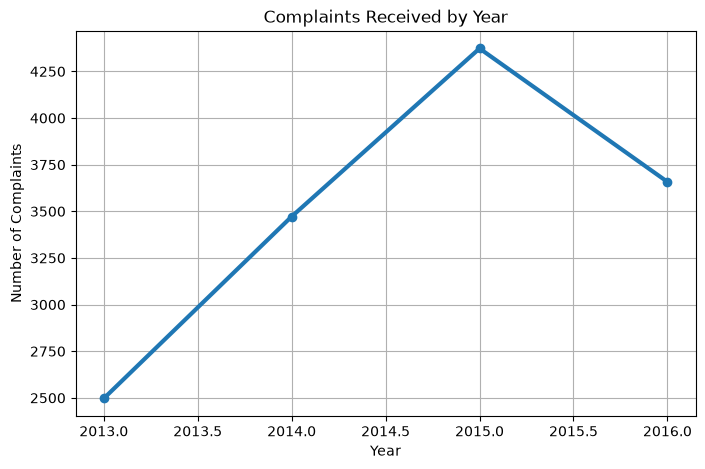

In [38]:
plt.figure(figsize=(8,5))

df["Complaint Year"].value_counts().sort_index().plot(
    kind="line",
    marker="o",
    linewidth=3
)

plt.title("Complaints Received by Year")

plt.xlabel("Year")

plt.ylabel("Number of Complaints")

plt.grid(True)

plt.show()

## Observation

Complaint volumes changed across different years.

Trend analysis helps identify whether consumer grievances are increasing or decreasing over time.

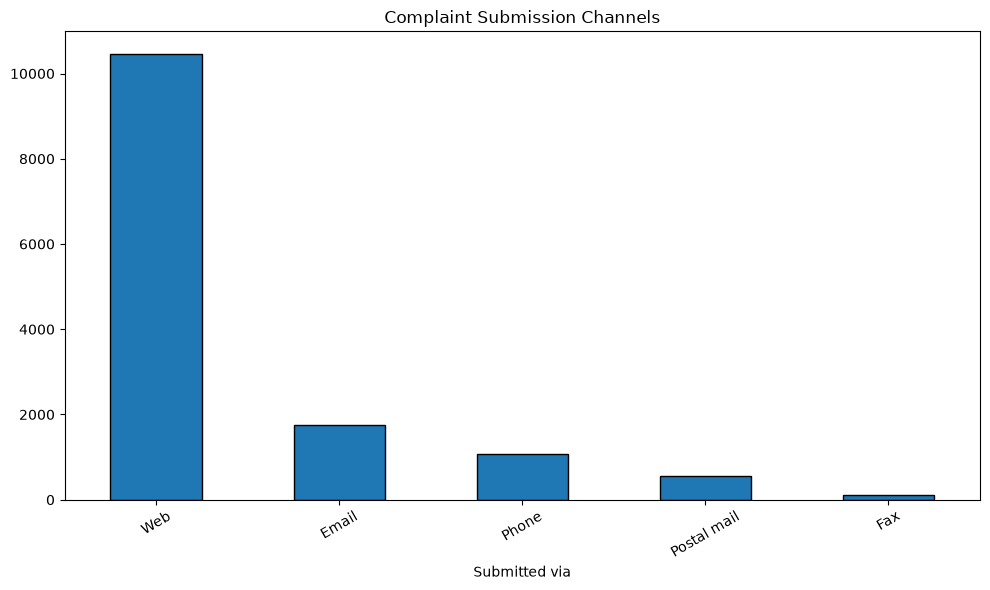

In [39]:
plt.figure(figsize=(10,6))

df["Submitted via"].value_counts().plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Complaint Submission Channels")

plt.xticks(rotation=30)

plt.tight_layout()

plt.show()

## Observation

Digital complaint channels dominate customer grievance submissions.

This indicates increasing adoption of online grievance redressal mechanisms.

In [40]:
df["Timely response?"].value_counts()

Timely response?
Yes    13775
No       225
Name: count, dtype: int64

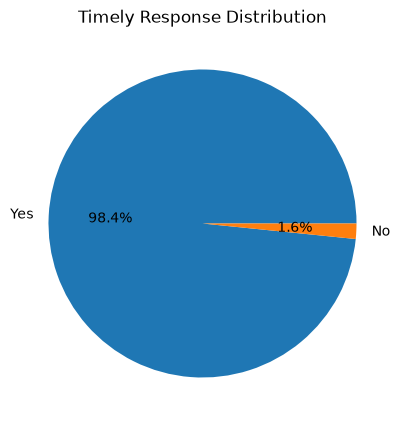

In [41]:
plt.figure(figsize=(6,5))

df["Timely response?"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")

plt.title("Timely Response Distribution")

plt.show()

## Observation

Most complaints received timely responses.

Monitoring this KPI helps evaluate institutional responsiveness.

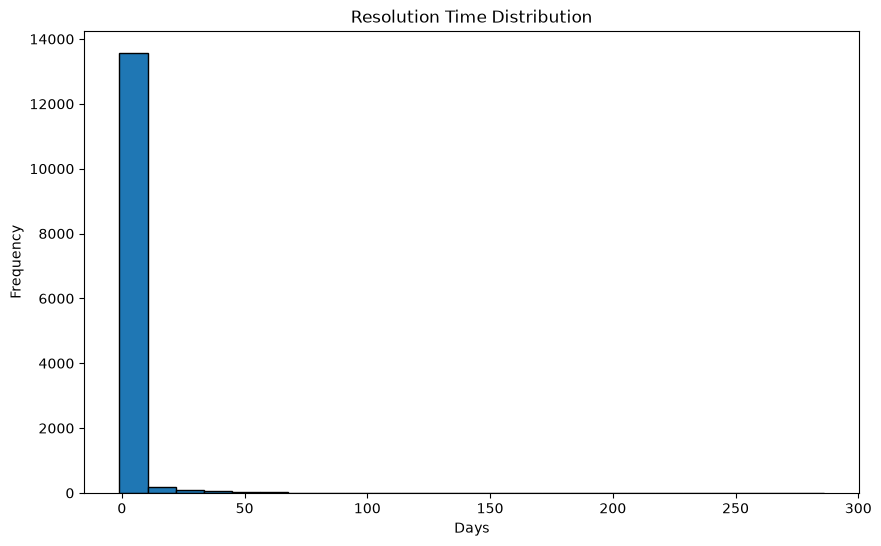

In [42]:
plt.figure(figsize=(10,6))

df["Resolution time(in days)"].plot(
    kind="hist",
    bins=25,
    edgecolor="black"
)

plt.title("Resolution Time Distribution")

plt.xlabel("Days")

plt.show()

## Observation

Complaint resolution times vary considerably.

Longer resolution times may indicate operational bottlenecks requiring management attention.

# Key Business Insights

1. Mortgage-related complaints constitute the largest complaint category.

2. A small number of complaint issues account for a significant share of all grievances.

3. Complaint volumes vary across companies, suggesting differences in customer service quality.

4. Digital channels are the primary mode of complaint submission.

5. Timely response rates appear high, indicating generally effective complaint handling.

# KPI Generation

In [43]:
total_complaints = len(df)

print(f"Total Complaints: {total_complaints:,}")

Total Complaints: 14,000


In [44]:
print(df["Company"].nunique())

1050


In [45]:
print(df["Product"].nunique())

12


In [46]:
round(df["Resolution time(in days)"].mean(),2)

np.float64(2.01)

In [47]:
df["Resolution time(in days)"].median()

np.float64(0.0)

In [48]:

(df["Timely response?"]=="Yes").mean()*100

np.float64(98.39285714285714)

# Executive Summary

## Objective

Analyse customer complaints received by financial institutions to identify complaint trends, customer pain points, operational performance, and areas requiring policy intervention.

## Key Findings

- Mortgage complaints constitute the largest complaint category.
- A limited number of issues account for a significant share of complaints.
- Digital channels dominate complaint submission.
- Average complaint resolution time is satisfactory but varies across cases.
- Most complaints receive timely responses.

## Recommendations

- Increase monitoring of high-volume complaint categories.
- Improve customer communication for recurring issues.
- Reduce complaint resolution time through workflow optimisation.
- Strengthen digital grievance management systems.

In [49]:
df.to_csv("../data/cleaned_complaints.csv",index=False)